<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 05: M&eacute;todos iterativos</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas F&uuml;hrer y Manuel A. Sánchez | <b>Fecha:</b> 17 de Abril, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li> 1. Sub- y sobre-relajacion </li>
        <li> 2. Valores y vectores propios. </li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-left: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> _______________________________________</li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> _________________________</li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')     
plt.rcParams['figure.figsize'] = (10, 6)
print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 1.26.4
Estilo usado: <function context at 0x72a5b8da3be0>


<div class="alert-block alert-warning "; style=" border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h2 > </h2>
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría:</h3>
    
**1. Método de Gauss-Seidel:**
La matriz de iteración es:
$$G_{GS} = -(D+L)^{-1}U$$

**2. Método SOR (Successive Over-Relaxation):**
Al introducir un parámetro de relajación $\omega$, la matriz de iteración se transforma en:
$$G_{SOR} = (D+\omega L)^{-1}((1-\omega)D - \omega U)$$

Demostraremos cómo el método clásico diverge, y cómo al utilizar sub-relajación ($\omega < 1$) logramos restaurar la convergencia del solver empujando los valores propios dentro del círculo unitario.
</div>



### Ejemplo 1: Sub-relajación (Under-relaxation)

Considere la matriz del sistema y el vector lado derecho son:

$$A = \begin{bmatrix} 2 & 3 & 0 \\ -5 & 2 & 3 \\ 0 & -5 & 2 \end{bmatrix}, \quad b = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}$$

Notemos que la matriz $A$ **no es simétrica** y ha perdido la **dominancia diagonal** en la segunda fila ($|2| < |-5| + |3|$). Descomponemos la matriz como $A = D + L + U$.

Para analizar la convergencia de los métodos iterativos, estudiamos el **radio espectral** $\rho(G)$ de su matriz de iteración $G$. El método converge si y solo si $\rho(G) < 1$.



--- Análisis de Convergencia Teórica ---
Radio espectral Jacobi: 2.7386 -> (>1 DIVERGE)
Radio espectral Gauss-Seidel: 7.5000 -> (>1 DIVERGE)
Radio espectral SOR (omega=0.51): 0.4900 -> (<1 CONVERGE)



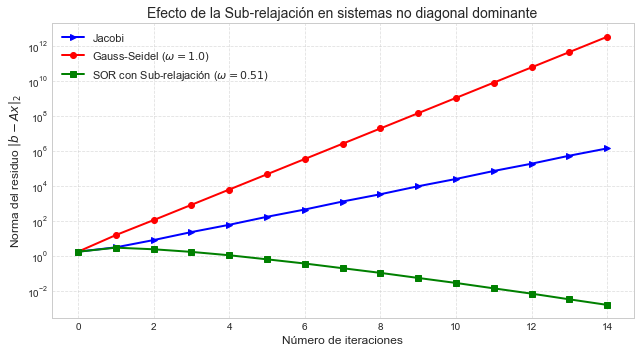

In [35]:
A = np.array([[2, 3, 0],
              [-5, 2, 3],
              [0, -5, 2]])
b = np.array([1, 1, 1])

# Descomposición de la matriz A
D = np.diag(np.diag(A)); L = np.tril(A, -1); U = np.triu(A, 1)

# Jacobi
G_J = -np.linalg.inv(D)@(L+U)
rho_J = np.max(np.abs(np.linalg.eigvals(G_J)))

# Gauss-Seidel (Equivalente a SOR con omega = 1.0)
G_GS = -np.linalg.inv(D + L) @ U
rho_GS = np.max(np.abs(np.linalg.eigvals(G_GS)))

# SOR con sub-relajación (omega = 0.5)
omega = .51
G_SOR = np.linalg.inv(D + omega * L) @ ((1 - omega) * D - omega * U)
rho_SOR = np.max(np.abs(np.linalg.eigvals(G_SOR)))

print("--- Análisis de Convergencia Teórica ---")
print(f"Radio espectral Jacobi: {rho_J:.4f} -> (>1 DIVERGE)")
print(f"Radio espectral Gauss-Seidel: {rho_GS:.4f} -> (>1 DIVERGE)")
print(f"Radio espectral SOR (omega={omega}): {rho_SOR:.4f} -> (<1 CONVERGE)\n")

def solver_iterativo(G, c, x0, num_iters):
    x = x0.copy()
    historial_residuo = []
    for _ in range(num_iters):
        # Calcular norma del residuo ||b - Ax||
        res = np.linalg.norm(b - A @ x)
        historial_residuo.append(res)
        # Actualizar paso
        x = G @ x + c
    return historial_residuo

# Condiciones iniciales y constantes de iteración
x0 = np.zeros(3)
iters = 15

c_J = np.linalg.inv(D ) @ b
c_GS = np.linalg.inv(D + L) @ b
c_SOR = omega * np.linalg.inv(D + omega * L) @ b

# Calcular historiales
res_J = solver_iterativo(G_J, c_J, x0, iters)
res_GS = solver_iterativo(G_GS, c_GS, x0, iters)
res_SOR = solver_iterativo(G_SOR, c_SOR, x0, iters)

# 4. Visualización de resultados para los estudiantes
plt.figure(figsize=(9, 5))
plt.plot(res_J, 'b->', linewidth=2, label=r'Jacobi')
plt.plot(res_GS, 'r-o', linewidth=2, label=r'Gauss-Seidel ($\omega=1.0$)')
plt.plot(res_SOR, 'g-s', linewidth=2, label=r'SOR con Sub-relajación ($\omega=0.51$)')

plt.yscale('log')
plt.xlabel('Número de iteraciones', fontsize=12)
plt.ylabel(r'Norma del residuo $\|b - Ax\|_2$', fontsize=12)
plt.title('Efecto de la Sub-relajación en sistemas no diagonal dominante', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

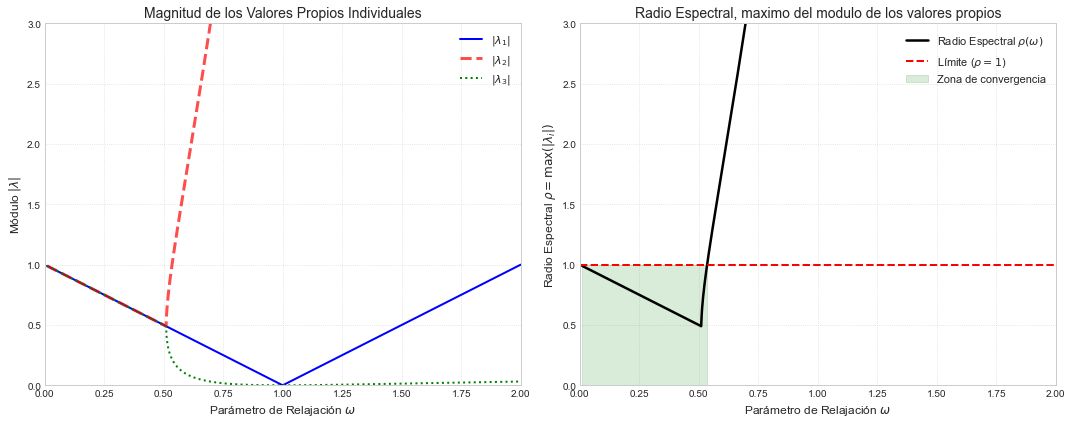

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el dominio de omega
omega = np.linspace(0.01, 2.0, 1000)

# 2. Calcular el discriminante y las raíces complejas
discriminante = (7.5*omega**2 + 2*omega - 2)**2 - 4*(1-omega)**2
raiz_disc = np.sqrt(discriminante.astype(complex))

# 3. Calcular los tres valores propios
lambda1 = 1 - omega
lambda2 = (-(7.5*omega**2 + 2*omega - 2) - raiz_disc) / 2.0
lambda3 = (-(7.5*omega**2 + 2*omega - 2) + raiz_disc) / 2.0

# 4. Calcular los módulos (magnitudes)
mod_L1 = np.abs(lambda1)
mod_L2 = np.abs(lambda2)
mod_L3 = np.abs(lambda3)

# 5. Calcular el radio espectral (el máximo de los módulos para cada omega)
rho = np.max([mod_L1, mod_L2, mod_L3], axis=0)

# 6. Crear la figura con subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- GRÁFICA IZQUIERDA: Módulos individuales ---
ax1.plot(omega, mod_L1, 'b-', linewidth=2, label=r'$|\lambda_1|$')
ax1.plot(omega, mod_L2, 'r--', linewidth=3, alpha=0.7, label=r'$|\lambda_2|$')
ax1.plot(omega, mod_L3, 'g:', linewidth=2, label=r'$|\lambda_3|$')

ax1.set_title('Magnitud de los Valores Propios Individuales', fontsize=14)
ax1.set_xlabel(r'Parámetro de Relajación $\omega$', fontsize=12)
ax1.set_ylabel(r'Módulo $|\lambda|$', fontsize=12)
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 3)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(fontsize=11)

# --- GRÁFICA DERECHA: Radio Espectral ---
ax2.plot(omega, rho, 'k-', linewidth=2.5, label=r'Radio Espectral $\rho(\omega)$')

# Límite de convergencia
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label=r'Límite ($\rho=1$)')

# Rellenar zona de convergencia
ax2.fill_between(omega, 0, 1, where=(rho < 1), color='green', alpha=0.15, label='Zona de convergencia')

ax2.set_title('Radio Espectral, maximo del modulo de los valores propios', fontsize=14)
ax2.set_xlabel(r'Parámetro de Relajación $\omega$', fontsize=12)
ax2.set_ylabel(r'Radio Espectral $\rho = \max(|\lambda_i|)$', fontsize=12)
ax2.set_xlim(0, 2)
ax2.set_ylim(0, 3)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(fontsize=11)

# Ajustar el espaciado y mostrar
plt.tight_layout()
plt.show()

### Ejemplo 1: Sobre-relajación (Over-relaxation)

Considere la matriz del sistema y el vector lado derecho son:

$$A = \begin{bmatrix} 4& 3&0 \\ 3 & 4 &-1 \\ 0&-1& 4\end{bmatrix}, \quad b = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}$$

Notemos que la matriz $A$ **es simétrica y definida positiva**  e **irreduciblemente diagonal**. Descomponemos la matriz como $A = D + L + U$.

Para analizar la convergencia de los métodos iterativos, estudiamos el **radio espectral** $\rho(G)$ de su matriz de iteración $G$. El método converge si y solo si $\rho(G) < 1$.


--- Análisis de Convergencia Teórica ---
Radio espectral Jacobi: 0.7906 -> (<1 CONVERGE)
Radio espectral Gauss-Seidel: 0.6250 -> (<1 CONVERGE)
Radio espectral SOR (omega=1.25): 0.2500 -> (<1 CONVERGE)



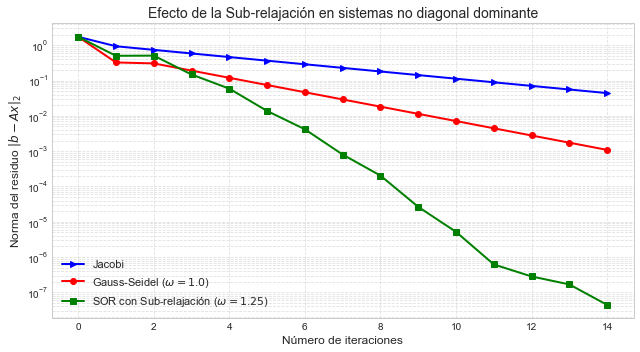

In [39]:
A = np.array([[4,3,0],[3,4,-1],[0,-1,4]],dtype = np.float64)
b = np.array([1, 1, 1])

# Descomposición de la matriz A
D = np.diag(np.diag(A)); L = np.tril(A, -1); U = np.triu(A, 1)

# Jacobi
G_J = -np.linalg.inv(D)@(L+U)
rho_J = np.max(np.abs(np.linalg.eigvals(G_J)))

# Gauss-Seidel (Equivalente a SOR con omega = 1.0)
G_GS = -np.linalg.inv(D + L) @ U
rho_GS = np.max(np.abs(np.linalg.eigvals(G_GS)))

# SOR con sub-relajación (omega = 0.5)
omega = 1.25
G_SOR = np.linalg.inv(D + omega * L) @ ((1 - omega) * D - omega * U)
rho_SOR = np.max(np.abs(np.linalg.eigvals(G_SOR)))

print("--- Análisis de Convergencia Teórica ---")
print(f"Radio espectral Jacobi: {rho_J:.4f} -> (<1 CONVERGE)")
print(f"Radio espectral Gauss-Seidel: {rho_GS:.4f} -> (<1 CONVERGE)")
print(f"Radio espectral SOR (omega={omega}): {rho_SOR:.4f} -> (<1 CONVERGE)\n")

def solver_iterativo(G, c, x0, num_iters):
    x = x0.copy()
    historial_residuo = []
    for _ in range(num_iters):
        # Calcular norma del residuo ||b - Ax||
        res = np.linalg.norm(b - A @ x)
        historial_residuo.append(res)
        # Actualizar paso
        x = G @ x + c
    return historial_residuo

# Condiciones iniciales y constantes de iteración
x0 = np.zeros(3)
iters = 15

c_J = np.linalg.inv(D ) @ b
c_GS = np.linalg.inv(D + L) @ b
c_SOR = omega * np.linalg.inv(D + omega * L) @ b

# Calcular historiales
res_J = solver_iterativo(G_J, c_J, x0, iters)
res_GS = solver_iterativo(G_GS, c_GS, x0, iters)
res_SOR = solver_iterativo(G_SOR, c_SOR, x0, iters)

# 4. Visualización de resultados para los estudiantes
plt.figure(figsize=(9, 5))
plt.plot(res_J, 'b->', linewidth=2, label=r'Jacobi')
plt.plot(res_GS, 'r-o', linewidth=2, label=r'Gauss-Seidel ($\omega=1.0$)')
plt.plot(res_SOR, 'g-s', linewidth=2, label=r'SOR con Sub-relajación ($\omega=1.25$)')

plt.yscale('log')
plt.xlabel('Número de iteraciones', fontsize=12)
plt.ylabel(r'Norma del residuo $\|b - Ax\|_2$', fontsize=12)
plt.title('Efecto de la Sub-relajación en sistemas no diagonal dominante', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

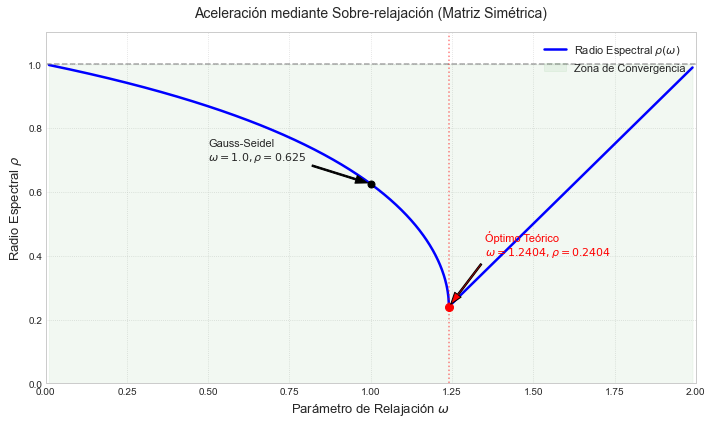

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el dominio de omega (0 < w < 2 para convergencia)
omega = np.linspace(0.01, 1.99, 1000)

# 2. Datos analíticos del problema elíptico (Simétrico)
rho_J_cuadrado = 0.625
rho_J = np.sqrt(rho_J_cuadrado)

# Calcular el omega óptimo según el Teorema de Young
w_opt = 2.0 / (1.0 + np.sqrt(1.0 - rho_J_cuadrado))

# 3. Función del radio espectral (piecewise para el caso SPD)
# El discriminante ahora es: w^2 * rho_J^2 - 4(w - 1)
discriminante = omega**2 * rho_J_cuadrado - 4*(omega - 1)

# En la zona de sobre-relajación óptima (w > w_opt), las raíces se vuelven 
# complejas conjugadas y el radio es simplemente w - 1
rho = np.where(
    omega <= w_opt,
    0.25 * (omega * rho_J + np.sqrt(np.maximum(0, discriminante)))**2, # Zona sub-óptima
    omega - 1 # Zona sobre-óptima
)

# 4. Crear la visualización para los estudiantes
plt.figure(figsize=(10, 6))

plt.plot(omega, rho, 'b-', linewidth=2.5, label=r'Radio Espectral $\rho(\omega)$')

# Marcar Gauss-Seidel (w = 1.0)
rho_GS = rho_J_cuadrado
plt.plot(1.0, rho_GS, 'ko', markersize=7)
plt.annotate(f'Gauss-Seidel\n$\\omega=1.0, \\rho={rho_GS:.3f}$', 
             xy=(1.0, rho_GS), xytext=(0.5, 0.7),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11)

# Marcar el óptimo absoluto
rho_opt = w_opt - 1
plt.plot(w_opt, rho_opt, 'ro', markersize=8)
plt.annotate(f'Óptimo Teórico\n$\\omega={w_opt:.4f}, \\rho={rho_opt:.4f}$', 
             xy=(w_opt, rho_opt), xytext=(1.35, 0.4),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, color='red')

# Detalles estéticos
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=w_opt, color='red', linestyle=':', alpha=0.5)
plt.fill_between(omega, 0, 1, color='green', alpha=0.05, label='Zona de Convergencia')

plt.title('Aceleración mediante Sobre-relajación (Matriz Simétrica)', fontsize=14, pad=15)
plt.xlabel(r'Parámetro de Relajación $\omega$', fontsize=13)
plt.ylabel(r'Radio Espectral $\rho$', fontsize=13)
plt.xlim(0, 2.0)
plt.ylim(0, 1.1)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

<div class="alert-block alert-warning "; style=" border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h2 > </h2>
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría: Metodo de la potencia.</h3>

Calcular valor propio mas grande de $A\in \mathbb R^{n\times n}$

Algoritmo. 
Input: $A, x^{(0)}$ con $\|x^{(0)}\|=1$

for $k=1,2,...$

1. $y = A x^{(k-1)}$
2. $x^{(k)} = y/\|y\|$
3. $\gamma^{(k)} = (v^{(k)})^{T} A v^{(k)}$
</div>

In [40]:
def iteracion_de_potencia(A, x0, TOL=1e-12, MAXITER=100):
    # Algorithm 9.1 (Numerical Analysis, Burden)
    x = x0.copy()
    p = np.argmax(np.abs(x))
    mu = 0
    iter=0
    mulist=[]; xlist=[]
    while np.linalg.norm(A.dot(x)-mu*x)>TOL and iter<MAXITER:
        y = A.dot(x)    
        mu = y[p]/x[p]
        # print(f"iteracion k = {iter}, A^k*x0 = {y}, mu = {mu}")
        p = np.argmax(np.abs(y))
        mulist.append(mu); xlist.append(x)
        x = y
        iter+=1
    return mulist, xlist

## Ejemplo: Iteracion de potencia
$$
A =
\begin{bmatrix}
-2& -3 \\
6 & 7
\end{bmatrix}
$$

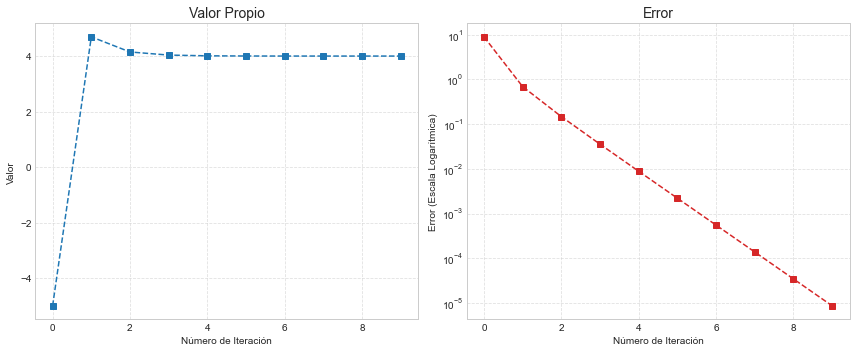

,iteracion k,mu^{(k)},error
0,0,-5.000000,9.000000
1,1,4.692308,0.692308
2,2,4.147541,0.147541
3,3,4.035573,0.035573
4,4,4.008815,0.008815
5,5,4.002199,0.002199
6,6,4.000549,0.000549
7,7,4.000137,0.000137
8,8,4.000034,0.000034
9,9,4.000009,0.000009


In [42]:
A1 = np.array([[-2,-3],[6,7]],dtype=np.float64); x0 = np.ones(2)
mu,x = iteracion_de_potencia(A1, x0, MAXITER=10)
# Convergencia
muexact = 4.0
mu2 = 1.0
error = [np.abs(mu[i]-muexact) for i in range(len(mu))]


# Figure
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(range(len(mu)), mu, '--s', color='tab:blue')
axs[0].set_title('Valor Propio', fontsize=14)
axs[0].set_xlabel('Número de Iteración')
axs[0].set_ylabel('Valor')
axs[0].grid(True, linestyle='--', alpha=0.6)

axs[1].semilogy(range(len(mu)), error, '--s', color='tab:red')
axs[1].set_title('Error', fontsize=14)
axs[1].set_xlabel('Número de Iteración')
axs[1].set_ylabel('Error (Escala Logarítmica)')
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(); plt.show()

import pandas as pd
df = pd.DataFrame({'iteracion k': np.arange(len(mu)), 'mu^{(k)}': mu, 'error': error})
df

## Ejemplo: Iteracion de potencia acelerada

\begin{equation}
A = 
\begin{pmatrix}
-4 & 14 & 0 \\
-5 & 13 & 0 \\
-1 & 0 & 2
\end{pmatrix}
\end{equation}

In [44]:
def iteracion_de_potencia_acelerada(A, x0, TOL=1e-12, MAXITER=100):
    '''
    Convergencia acelerada usando Aitken
    '''
    x = x0.copy()
    p = np.argmax(np.abs(x))
    mu = 0
    iter=0
    mulist=[]; xlist=[]
    # Aitken
    mu0 = 0.0; mu1 = 0.0; muhatlist = []
    while np.linalg.norm(A.dot(x)-mu*x)>TOL and iter<MAXITER:
        y = A.dot(x)    
        mu = y[p]
        muhat = mu0-(mu1-mu0)**2/(mu - 2.0*mu1 + mu0)
        # print(muhat)
        muhatlist.append(muhat);
        mu0 = mu1; mu1 = mu
        # print(f"iteracion k = {iter}, A^k*x0 = {y}, mu = {mu}, muhat = {muhat}")
        p = np.argmax(np.abs(y))
        xlist.append(x)
        x = y/y[p]
        iter+=1
    return muhatlist, xlist

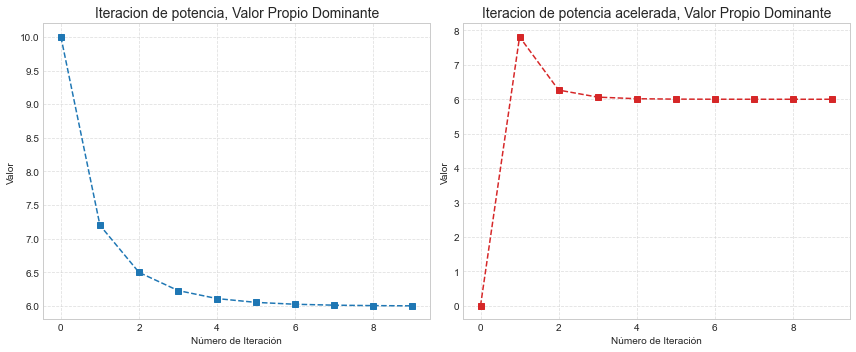

,iteracion k,mu^{(k)},error,muhat^{(k)},errorhat
0,0,10.000000,4.000000,0.000000,6.000000
1,1,7.200000,1.200000,7.812500,1.812500
2,2,6.500000,0.500000,6.266667,0.266667
3,3,6.230769,0.230769,6.062500,0.062500
4,4,6.111111,0.111111,6.015385,0.015385
5,5,6.054545,0.054545,6.003831,0.003831
6,6,6.027027,0.027027,6.000957,0.000957
7,7,6.013453,0.013453,6.000239,0.000239
8,8,6.006711,0.006711,6.000060,0.000060
9,9,6.003352,0.003352,6.000015,0.000015


In [45]:
A2 = np.array([[-4,14,0],[-5,13,0],[-1,0,2]],dtype=np.float64); x0 = np.ones(3)
# iteracion de potencia
mu,x = iteracion_de_potencia(A2, x0, MAXITER=10)
# iteracion de potencia acelerada
A2 = np.array([[-4,14,0],[-5,13,0],[-1,0,2]],dtype=np.float64); x0 = np.ones(3)
muhat,x = iteracion_de_potencia_acelerada(A2, x0, MAXITER=10)

# Figure
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(range(len(mu)), mu, '--s', color='tab:blue')
axs[0].set_title('Iteracion de potencia, Valor Propio Dominante', fontsize=14)
axs[0].set_xlabel('Número de Iteración')
axs[0].set_ylabel('Valor')
axs[0].grid(True, linestyle='--', alpha=0.6)

axs[1].plot(range(len(muhat)), muhat, '--s', color='tab:red')
axs[1].set_title('Iteracion de potencia acelerada, Valor Propio Dominante', fontsize=14)
axs[1].set_xlabel('Número de Iteración')
axs[1].set_ylabel('Valor')
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(); plt.show()


# Convergencia
muexact = 6.0
error = [np.abs(mu[i]-muexact) for i in range(len(mu))]
errorhat = [np.abs(muhat[i]-muexact) for i in range(len(muhat))]
df = pd.DataFrame({'iteracion k': np.arange(len(mu)), 'mu^{(k)}': mu, 'error': error,  'muhat^{(k)}': muhat, 'errorhat': errorhat })
df